# GB Power Imbalance Risk Agent

## Step 3: train and test the risk model

The model estimates the probability that the GB electricity system will be short in each settlement period. This is a risk forecast, not a trading strategy.

The timeline is fixed before we look at the results:

- 2022 to 2023: training
- 2024: model selection
- 2025: untouched final test

## 1. Imports

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Load the files

Keep `power_history.csv` and `excluded_dates.csv` in the same folder as this notebook.

In [2]:
HISTORY_FILE = Path("power_history.csv")
EXCLUSIONS_FILE = Path("excluded_dates.csv")
RANDOM_SEED = 42

assert HISTORY_FILE.exists(), "power_history.csv is missing"
assert EXCLUSIONS_FILE.exists(), "excluded_dates.csv is missing"

history = pd.read_csv(HISTORY_FILE)
exclusions = pd.read_csv(EXCLUSIONS_FILE)

print(f"Loaded {len(history):,} history rows")
print(f"Loaded {len(exclusions):,} exclusion records")

Loaded 70,128 history rows
Loaded 9 exclusion records


## 3. Recreate the clean modelling sample

The uploaded history may still contain the complete raw schedule. We therefore enforce the exclusion policy again here.

A date with an unavailable forecast feature is removed in full. An isolated row with no realised NIV is removed because it has no target label. Nothing is imputed.

In [3]:
RAW_FEATURES = ["demand", "generation", "imbalance", "margin"]
TARGET = "system_short"
KEYS = ["settlementDate", "settlementPeriod"]

whole_date_exclusions = set(
    exclusions.loc[
        exclusions["scope"] == "whole date",
        "settlementDate",
    ].astype(str)
)

model_data = history.loc[
    ~history["settlementDate"].astype(str).isin(whole_date_exclusions)
].copy()

model_data = model_data.dropna(
    subset=RAW_FEATURES + ["netImbalanceVolume", TARGET]
).copy()
model_data[TARGET] = model_data[TARGET].astype(int)

assert model_data.duplicated(KEYS).sum() == 0
assert model_data[RAW_FEATURES + [TARGET]].isna().sum().sum() == 0
assert (
    model_data[TARGET]
    == (model_data["netImbalanceVolume"] > 0).astype(int)
).all()
assert len(model_data) == 69_926, "Unexpected modelling row count"

cleaning_summary = pd.Series({
    "raw rows": len(history),
    "whole forecast dates removed": len(whole_date_exclusions),
    "total rows removed": len(history) - len(model_data),
    "clean modelling rows": len(model_data),
})

cleaning_summary

raw rows                        70128
whole forecast dates removed        4
total rows removed                202
clean modelling rows            69926
dtype: int64

## 4. Construct point-in-time features

Every model input was available by the 16:00 cutoff on D-1. Realised NIV, system price and outcome timestamps are deliberately excluded.

The ratios make forecasts comparable across high-demand and low-demand periods. The sine and cosine terms represent repeating calendar cycles without treating midnight as far away from 23:30.

In [4]:
def construct_model_features(frame):
    data = frame.copy()
    dates = pd.to_datetime(data["settlementDate"])

    data["residual_demand"] = data["demand"] - data["generation"]
    data["wind_share"] = data["generation"] / data["demand"]
    data["margin_ratio"] = data["margin"] / data["demand"]
    data["imbalance_ratio"] = data["imbalance"] / data["demand"]

    data["hour_sin"] = np.sin(2 * np.pi * data["local_hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["local_hour"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)
    data["month_sin"] = np.sin(2 * np.pi * (dates.dt.month - 1) / 12)
    data["month_cos"] = np.cos(2 * np.pi * (dates.dt.month - 1) / 12)
    data["year"] = dates.dt.year

    return data


FEATURES = [
    "demand",
    "generation",
    "imbalance",
    "margin",
    "residual_demand",
    "wind_share",
    "margin_ratio",
    "imbalance_ratio",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "is_weekend",
]

model_data = construct_model_features(model_data)
assert model_data[FEATURES].isna().sum().sum() == 0

model_data[FEATURES].head()

,demand,generation,imbalance,margin,residual_demand,wind_share,margin_ratio,imbalance_ratio,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend
0,21450.0,9452,1078.0,39022,11998.0,0.440653,1.819207,0.050256,0.000000,1.000000,-0.974928,-0.222521,0.0,1.0,1
1,21860.0,9452,764.0,38497,12408.0,0.432388,1.761070,0.034950,0.130526,0.991445,-0.974928,-0.222521,0.0,1.0,1
2,21400.0,10212,-161.0,37492,11188.0,0.477196,1.751963,-0.007523,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0,1
3,20336.0,10212,1086.0,38521,10124.0,0.502164,1.894227,0.053403,0.382683,0.923880,-0.974928,-0.222521,0.0,1.0,1
4,19349.0,11042,253.0,37369,8307.0,0.570675,1.931314,0.013076,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0,1


## 5. Make the chronological split

There is no random train-test split. Later years must remain later years.

In [5]:
train_mask = model_data["year"] <= 2023
validation_mask = model_data["year"] == 2024
test_mask = model_data["year"] == 2025

split_table = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "period": ["2022 to 2023", "2024", "2025"],
    "rows": [train_mask.sum(), validation_mask.sum(), test_mask.sum()],
    "short_rate": [
        model_data.loc[train_mask, TARGET].mean(),
        model_data.loc[validation_mask, TARGET].mean(),
        model_data.loc[test_mask, TARGET].mean(),
    ],
})

assert split_table["rows"].tolist() == [34_838, 17_568, 17_520]
split_table

,split,period,rows,short_rate
0,Train,2022 to 2023,34838,0.503473
1,Validation,2024,17568,0.475808
2,Test,2025,17520,0.459760


## 6. Define the benchmark and nonlinear model

Logistic regression is the transparent benchmark. Extra Trees is the nonlinear candidate. Its settings are deliberately conservative so individual half-hours do not create tiny, unstable leaves.

The constant model simply predicts the training-period short rate for every row.

In [6]:
def build_models():
    return {
        "Logistic regression": Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                C=0.01,
                max_iter=1000,
                random_state=RANDOM_SEED,
            )),
        ]),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=100,
            max_features=1.0,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
    }


def expected_calibration_error(actual, probability, bins=10):
    table = pd.DataFrame({
        "actual": np.asarray(actual),
        "probability": np.asarray(probability),
    })
    table["bin"] = pd.cut(
        table["probability"],
        bins=np.linspace(0, 1, bins + 1),
        include_lowest=True,
    )
    grouped = table.groupby("bin", observed=True).agg(
        rows=("actual", "size"),
        actual_rate=("actual", "mean"),
        mean_probability=("probability", "mean"),
    )
    return (
        grouped["rows"]
        * (grouped["actual_rate"] - grouped["mean_probability"]).abs()
    ).sum() / grouped["rows"].sum()


def score_predictions(actual, probability):
    return {
        "auc": roc_auc_score(actual, probability),
        "brier": brier_score_loss(actual, probability),
        "log_loss": log_loss(actual, probability),
        "accuracy": accuracy_score(actual, probability >= 0.5),
        "ece_10_bins": expected_calibration_error(actual, probability),
        "mean_probability": probability.mean(),
        "actual_short_rate": actual.mean(),
    }

## 7. Select the model using 2024 only

The model with the lowest 2024 Brier score wins. Brier score measures the quality of the probability itself, not only whether the ranking is correct.

In [7]:
X_train = model_data.loc[train_mask, FEATURES]
y_train = model_data.loc[train_mask, TARGET]
X_validation = model_data.loc[validation_mask, FEATURES]
y_validation = model_data.loc[validation_mask, TARGET]

validation_rows = []
training_probability = y_train.mean()
constant_validation = np.repeat(training_probability, len(y_validation))
validation_rows.append({
    "model": "Constant baseline",
    **score_predictions(y_validation, constant_validation),
})

validation_models = build_models()
for model_name, model in validation_models.items():
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_validation)[:, 1]
    validation_rows.append({
        "model": model_name,
        **score_predictions(y_validation, probability),
    })

validation_results = pd.DataFrame(validation_rows).sort_values("brier")
champion_name = validation_results.loc[
    validation_results["model"] != "Constant baseline"
].iloc[0]["model"]

assert champion_name == "Extra Trees", "Validation selected a different model"
print(f"Selected model: {champion_name}")
validation_results

Selected model: Extra Trees


,model,auc,brier,log_loss,accuracy,ece_10_bins,mean_probability,actual_short_rate
2,Extra Trees,0.644236,0.233492,0.659078,0.604053,0.008411,0.475311,0.475808
1,Logistic regression,0.633988,0.237230,0.667867,0.595571,0.025657,0.501466,0.475808
0,Constant baseline,0.500000,0.250180,0.693507,0.475808,0.027665,0.503473,0.475808


## 8. Run the untouched 2025 test

The specification is now frozen. We refit both models through the end of 2024 and evaluate 2025 once.

In [8]:
development_mask = model_data["year"] <= 2024

X_development = model_data.loc[development_mask, FEATURES]
y_development = model_data.loc[development_mask, TARGET]
X_test = model_data.loc[test_mask, FEATURES]
y_test = model_data.loc[test_mask, TARGET]

test_rows = []
test_probabilities = {}
development_probability = y_development.mean()
constant_test = np.repeat(development_probability, len(y_test))
test_rows.append({
    "model": "Constant baseline",
    **score_predictions(y_test, constant_test),
})

test_models = build_models()
for model_name, model in test_models.items():
    model.fit(X_development, y_development)
    probability = model.predict_proba(X_test)[:, 1]
    test_probabilities[model_name] = probability
    test_rows.append({
        "model": model_name,
        **score_predictions(y_test, probability),
    })

test_results = pd.DataFrame(test_rows).sort_values("brier")
champion_test_probability = test_probabilities[champion_name]
test_results

,model,auc,brier,log_loss,accuracy,ece_10_bins,mean_probability,actual_short_rate
2,Extra Trees,0.632101,0.235238,0.662739,0.598573,0.012849,0.461529,0.45976
1,Logistic regression,0.613714,0.241406,0.677088,0.589041,0.029557,0.480604,0.45976
0,Constant baseline,0.500000,0.249567,0.692281,0.540240,0.034439,0.494199,0.45976


## 9. Apply the performance gate

A useful result must beat the constant probability forecast in both 2024 and 2025. We also require test AUC above 0.60.

In [9]:
validation_champion = validation_results.set_index("model").loc[champion_name]
validation_constant = validation_results.set_index("model").loc["Constant baseline"]
test_champion = test_results.set_index("model").loc[champion_name]
test_constant = test_results.set_index("model").loc["Constant baseline"]

assert validation_champion["brier"] < validation_constant["brier"]
assert test_champion["brier"] < test_constant["brier"]
assert test_champion["auc"] >= 0.60

brier_skill = 1 - test_champion["brier"] / test_constant["brier"]

print("PASS: the nonlinear model adds out-of-sample information.")
print(f"2025 AUC: {test_champion['auc']:.3f}")
print(f"2025 Brier score: {test_champion['brier']:.3f}")
print(f"Brier improvement over constant: {brier_skill:.1%}")

PASS: the nonlinear model adds out-of-sample information.
2025 AUC: 0.632
2025 Brier score: 0.235
Brier improvement over constant: 5.7%


## 10. Use date-block confidence intervals

Half-hours from the same day are related. The bootstrap therefore resamples complete settlement dates instead of pretending that every row is independent.

In [10]:
def date_block_bootstrap(actual, probability, dates, baseline_probability, repeats=500):
    sample = pd.DataFrame({
        "actual": np.asarray(actual),
        "probability": np.asarray(probability),
        "date": np.asarray(dates),
    })
    groups = {
        settlement_date: group.index.to_numpy()
        for settlement_date, group in sample.groupby("date")
    }
    unique_dates = np.array(list(groups))
    rng = np.random.default_rng(RANDOM_SEED)
    results = []

    for _ in range(repeats):
        sampled_dates = rng.choice(
            unique_dates, size=len(unique_dates), replace=True
        )
        indices = np.concatenate([groups[d] for d in sampled_dates])
        sampled_actual = sample["actual"].to_numpy()[indices]
        sampled_probability = sample["probability"].to_numpy()[indices]
        model_brier = brier_score_loss(
            sampled_actual, sampled_probability
        )
        baseline_brier = brier_score_loss(
            sampled_actual,
            np.repeat(baseline_probability, len(sampled_actual)),
        )
        results.append({
            "auc": roc_auc_score(sampled_actual, sampled_probability),
            "brier": model_brier,
            "brier_skill": 1 - model_brier / baseline_brier,
        })

    return pd.DataFrame(results)


test_dates = model_data.loc[test_mask, "settlementDate"]
bootstrap = date_block_bootstrap(
    y_test,
    champion_test_probability,
    test_dates,
    development_probability,
)

confidence_intervals = bootstrap.quantile([0.025, 0.975])
confidence_intervals.index = ["2.5%", "97.5%"]
confidence_intervals

,auc,brier,brier_skill
2.5%,0.617300,0.231868,0.043377
97.5%,0.646654,0.238856,0.070417


## 11. Check calibration and risk ranking

A useful probability model should place more genuinely short periods in its high-risk groups.

In [11]:
test_evaluation = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "probability": champion_test_probability,
})
test_evaluation["risk_decile"] = pd.qcut(
    test_evaluation["probability"],
    10,
    labels=range(1, 11),
)

decile_table = test_evaluation.groupby(
    "risk_decile", observed=True
).agg(
    periods=("actual", "size"),
    mean_probability=("probability", "mean"),
    actual_short_rate=("actual", "mean"),
)

decile_table

,periods,mean_probability,actual_short_rate
risk_decile,,,
1,1752,0.229176,0.244292
2,1752,0.326572,0.350457
3,1752,0.375098,0.389269
4,1752,0.411659,0.392694
5,1752,0.446745,0.453196
6,1752,0.482807,0.476598
7,1752,0.518795,0.515982
8,1752,0.556030,0.523402
9,1752,0.595870,0.593607


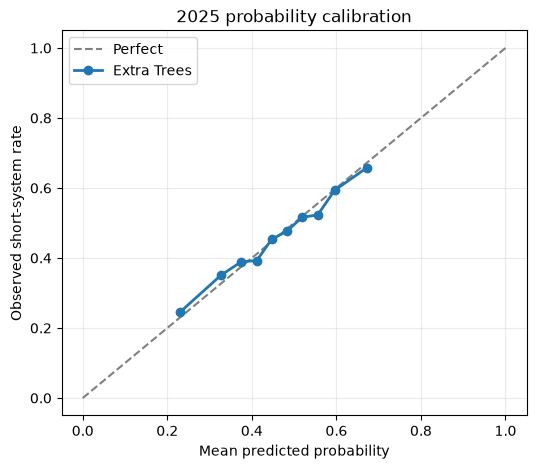

In [12]:
observed_rate, predicted_rate = calibration_curve(
    y_test, champion_test_probability, n_bins=10, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect")
ax.plot(
    predicted_rate,
    observed_rate,
    marker="o",
    linewidth=2,
    label=champion_name,
)
ax.set(
    title="2025 probability calibration",
    xlabel="Mean predicted probability",
    ylabel="Observed short-system rate",
)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 12. Explain the model

Permutation importance measures how much the 2025 Brier score worsens when one feature is shuffled. It is descriptive and is not used to retune the model.

In [13]:
importance_sample = X_test.sample(
    n=min(5_000, len(X_test)), random_state=RANDOM_SEED
)
importance_target = y_test.loc[importance_sample.index]

importance_result = permutation_importance(
    test_models[champion_name],
    importance_sample,
    importance_target,
    scoring="neg_brier_score",
    n_repeats=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "brier_importance": importance_result.importances_mean,
    "importance_std": importance_result.importances_std,
}).sort_values("brier_importance", ascending=False)

feature_importance

,feature,brier_importance,importance_std
7,imbalance_ratio,0.003184,0.000456
2,imbalance,0.002311,0.000506
6,margin_ratio,0.002077,0.000455
13,month_cos,0.001901,0.000306
8,hour_sin,0.001696,0.000199
9,hour_cos,0.001470,0.000330
14,is_weekend,0.001052,0.000141
11,dow_cos,0.000190,0.000148
0,demand,0.000143,0.000212
10,dow_sin,0.000131,0.000096


## 13. Save the evaluated model and outputs

Only after the 2025 evaluation is recorded do we refit the production models on all four years. The saved bundle contains both the nonlinear champion and the logistic benchmark so the later agent can report model disagreement.

In [14]:
metrics_output = pd.concat([
    validation_results.assign(stage="2024 validation"),
    test_results.assign(stage="2025 test"),
], ignore_index=True)

predictions_output = model_data.loc[
    test_mask,
    ["settlementDate", "settlementPeriod", "startTime", TARGET],
].copy()
predictions_output["extra_trees_probability"] = test_probabilities["Extra Trees"]
predictions_output["logistic_probability"] = test_probabilities["Logistic regression"]
predictions_output["champion_probability"] = champion_test_probability
predictions_output["risk_decile"] = pd.qcut(
    predictions_output["champion_probability"],
    10,
    labels=range(1, 11),
).astype(int)

production_models = build_models()
for model in production_models.values():
    model.fit(model_data[FEATURES], model_data[TARGET])

model_bundle = {
    "champion_name": champion_name,
    "champion_model": production_models[champion_name],
    "benchmark_model": production_models["Logistic regression"],
    "features": FEATURES,
    "raw_features": RAW_FEATURES,
    "trained_through": "2025-12-31",
    "training_rows": len(model_data),
    "cutoff_policy": "16:00 Europe/London on D-1",
    "test_metrics": test_champion.to_dict(),
}

joblib.dump(model_bundle, "power_risk_model.joblib")
metrics_output.to_csv("model_metrics.csv", index=False)
predictions_output.to_csv("test_predictions.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

print("Saved power_risk_model.joblib")
print("Saved model_metrics.csv")
print("Saved test_predictions.csv")
print("Saved feature_importance.csv")

Saved power_risk_model.joblib
Saved model_metrics.csv
Saved test_predictions.csv
Saved feature_importance.csv


In [15]:
# Copy the important outputs into one folder

from pathlib import Path
from shutil import copy2


output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)

important_files = [
    "model_metrics.csv",
    "test_predictions.csv",
    "feature_importance.csv",
    "excluded_dates.csv",
    "power_risk_model.joblib",
    "agent_audit.json",
]

saved_files = []

for file_name in important_files:
    source = Path(file_name)

    if source.exists():
        destination = output_folder / file_name
        copy2(source, destination)
        saved_files.append(file_name)

print(f"Saved {len(saved_files)} files to: {output_folder.resolve()}")

for file_name in saved_files:
    print(f"- {file_name}")

Saved 5 files to: C:\Users\rijul\Python Codes\GP Power Risk Agent\gb_power_risk_agent\outputs
- model_metrics.csv
- test_predictions.csv
- feature_importance.csv
- excluded_dates.csv
- power_risk_model.joblib


## What this step proves

The model contains useful but moderate out-of-sample information. Its value is risk ranking and probability estimation, not proof of a tradable strategy.

The next step is to expose the validated data checks, prediction, explanation and scenario functions as deterministic tools. Ollama will then decide which tools to call and write a grounded risk brief.